# XÂY DỰNG MÔ HÌNH MACHINE LEARNING XGBOOST, LIGHTGBM VÀ RANDOMFOREST KẾT HỢP KỸ THUẬT GRIDSEARCHCV TRÊN TẬP DỮ LIỆU LEADING SOCRE

## Load và phân tích dữ liệu

In [2]:
import pandas as pd

In [3]:
data_train = pd.read_csv("data/Leads_Selected_Train.csv")
data_test = pd.read_csv("data/Leads_Selected_Test.csv")

In [4]:
X_train = data_train.drop(columns=["Converted"])
y_train = data_train["Converted"]
X_test = data_test.drop(columns=["Converted"])
y_test = data_test["Converted"]

In [5]:
print(f"Số mẫu dữ liệu trong tập train {len(X_train)}")
print(f"Số mẫu dữ liệu trong tập test {len(X_test)}")

Số mẫu dữ liệu trong tập train 6152
Số mẫu dữ liệu trong tập test 1538


In [6]:
print("Nhãn trong tập train")
y_train.value_counts()

Nhãn trong tập train


Converted
0    3699
1    2453
Name: count, dtype: int64

In [7]:
print("Nhãn trong tập test")
y_test.value_counts()

Nhãn trong tập test


Converted
0    936
1    602
Name: count, dtype: int64

## Mô hình XGBoost với GridSearchCV

In [8]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [9]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss"
)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=3,
)

In [10]:
grid_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=3)

In [11]:
best_xgb = grid_xgb.best_estimator_
print(f"Best parameters: {grid_xgb.best_params_}")

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [12]:
xgb_model_file = "models/xgb_best_model.pkl"
print(f"Lưu mô hình tốt nhất tại {xgb_model_file}")
with open(xgb_model_file, "wb") as f:
    pickle.dump(best_xgb, f)

Lưu mô hình tốt nhất tại models/xgb_best_model.pkl


In [13]:
# Đánh giá
y_xgb_predict = best_xgb.predict(X_test)

In [14]:
xgb_report = classification_report(y_xgb_predict, y_test)
print("Kết quả đánh giá:")
print(xgb_report)

Kết quả đánh giá:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       954
           1       0.77      0.79      0.78       584

    accuracy                           0.83      1538
   macro avg       0.82      0.82      0.82      1538
weighted avg       0.83      0.83      0.83      1538



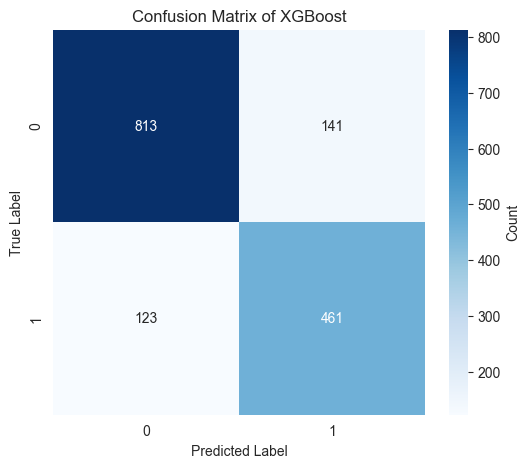

In [15]:
import seaborn as sns

cm_xgb = confusion_matrix(y_xgb_predict, y_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix of XGBoost")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig("confusion_matrix/confusion_matrix_XGB.png", dpi=300, bbox_inches='tight')
plt.show()

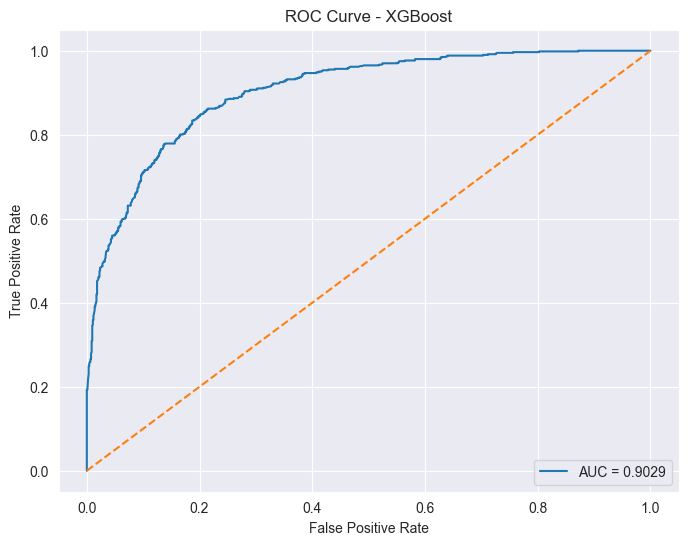

In [16]:
# Vẽ AUC
y_prob = best_xgb.predict_proba(X_test)[:, 1]
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")
plt.savefig("auc/auc_XGB.png", dpi=300, bbox_inches='tight')
plt.show()

## Mô hình LightGBM với GridSearchCV

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [18]:
lgb_model = LGBMClassifier()

param_grid_lgb = {
    'n_estimators': [100, 200],
    'num_leaves': [31, 50],
    'max_depth': [-1, 10, 20],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_lgb = GridSearchCV(
    estimator=lgb_model,
    param_grid=param_grid_lgb,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=2,
)

In [19]:
grid_lgb.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2453, number of negative: 3699
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000134 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 353
[LightGBM] [Info] Number of data points in the train set: 6152, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.398732 -> initscore=-0.410751
[LightGBM] [Info] Start training from score -0.410751


GridSearchCV(cv=5, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1],
                         'max_depth': [-1, 10, 20], 'n_estimators': [100, 200],
                         'num_leaves': [31, 50], 'subsample': [0.8, 1.0]},
             scoring='f1', verbose=2)

In [20]:
best_lbg = grid_lgb.best_estimator_
print(f"Best parameters: {grid_lgb.best_params_}")

Best parameters: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}


In [21]:
lgb_model_file = "models/lgb_best_model.pkl"
print(f"Lưu mô hình tốt nhất tại {lgb_model_file}")
with open(lgb_model_file, "wb") as f:
    pickle.dump(best_lbg, f)

Lưu mô hình tốt nhất tại models/lgb_best_model.pkl


In [22]:
y_lgb_predict = best_lbg.predict(X_test)

In [23]:
lgb_report = classification_report(y_lgb_predict, y_test)
print("Kết quả đánh giá:")
print(lgb_report)

Kết quả đánh giá:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       946
           1       0.76      0.77      0.77       592

    accuracy                           0.82      1538
   macro avg       0.81      0.81      0.81      1538
weighted avg       0.82      0.82      0.82      1538



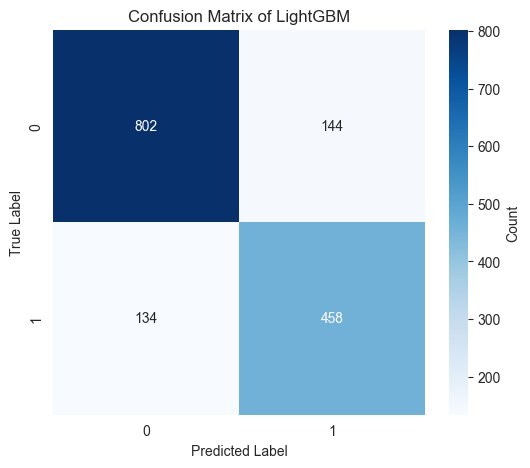

In [24]:
import seaborn as sns

cm_lgb = confusion_matrix(y_lgb_predict, y_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix of LightGBM")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig("confusion_matrix/confusion_matrix_LGB.png", dpi=300, bbox_inches='tight')
plt.show()

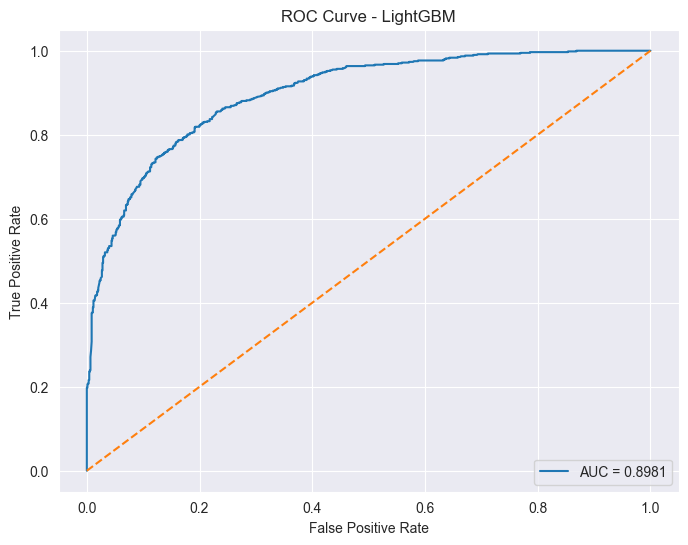

In [25]:
# Vẽ AUC
y_prob = best_lbg.predict_proba(X_test)[:, 1]
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LightGBM")
plt.legend(loc="lower right")
plt.savefig("auc/auc_LGB.png", dpi=300, bbox_inches='tight')
plt.show()

## Mô hình RandomForest với GridSearchCV

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

In [27]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
# Grid Search
grid_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

In [28]:
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [29]:
best_rf = grid_rf.best_estimator_
print(f"Best parameters: {grid_rf.best_params_}")

Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [30]:
rf_model_file = "models/rf_best_model.pkl"
print(f"Lưu mô hình tốt nhất tại {rf_model_file}")
with open(rf_model_file, "wb") as f:
    pickle.dump(best_rf, f)

Lưu mô hình tốt nhất tại models/rf_best_model.pkl


In [31]:
y_rf_predict = best_rf.predict(X_test)

In [32]:
rf_report = classification_report(y_rf_predict, y_test)
print("Kết quả đánh giá:")
print(rf_report)

Kết quả đánh giá:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86       957
           1       0.76      0.79      0.78       581

    accuracy                           0.83      1538
   macro avg       0.82      0.82      0.82      1538
weighted avg       0.83      0.83      0.83      1538



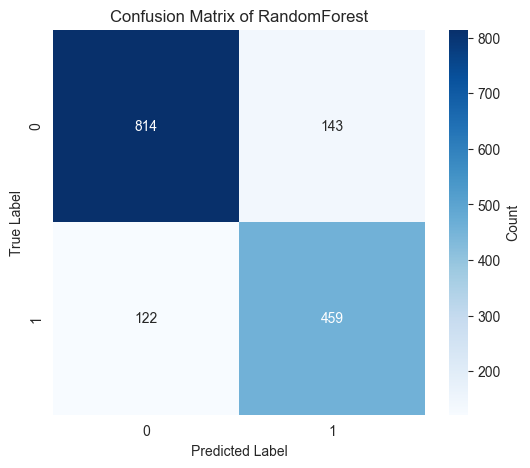

In [34]:
import seaborn as sns

cm_rf = confusion_matrix(y_rf_predict, y_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Count'})
plt.title("Confusion Matrix of RandomForest")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig("confusion_matrix/confusion_matrix_RF.png", dpi=300, bbox_inches='tight')
plt.show()

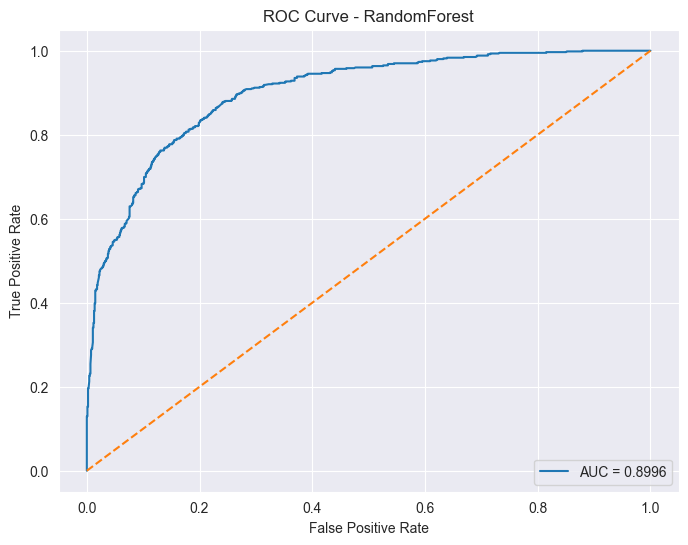

In [35]:
# Vẽ AUC
y_prob = best_rf.predict_proba(X_test)[:, 1]
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RandomForest")
plt.legend(loc="lower right")
plt.savefig("auc/auc_RF.png", dpi=300, bbox_inches='tight')
plt.show()